In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 오류 해결
from matplotlib import font_manager

font_path = './drive/MyDrive/data/Part4/malgun.ttf'

# 폰트 파일을 font_manager에 추가하여 matplotlib이 폰트를 찾게 함
font_manager.fontManager.addfont(font_path)

# 추가된 폰트의 이름을 가져옴
font_name = font_manager.FontProperties(fname=font_path).get_name()

# 전역 폰트 설정 변경
plt.rcParams['font.family'] = font_name
# 마이너스 부호가 깨지는 것을 방지
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비

In [2]:
# 데이터 불러오기(대기오염, 자동차 등록대수 자료 / 엑셀파일)
air_original = pd.read_excel('/content/drive/MyDrive/project02/air_pol.xlsx')
car_original = pd.read_excel('/content/drive/MyDrive/project02/car_reg.xlsx')

display(air_original)
display(car_original)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,기준별(1),시점,아황산가스(SO2) (ppm/년),일산화탄소(CO) (ppm/8시간),이산화질소(NO2) (ppm/년),미세먼지(PM-10) (㎍/㎥/년),초미세먼지(PM-2.5) (㎍/㎥/년),오존(O3) (ppm/8시간)
0,대기오염,2018. 01,0.0060,0.60,0.0350,52,32,0.0140
1,대기오염,2018. 02,0.0050,0.60,0.0340,53,30,0.0180
2,대기오염,2018. 03,0.0050,0.60,0.0330,52,34,0.0260
3,대기오염,2018. 04,0.0040,0.50,0.0310,52,26,0.0310
4,대기오염,2018. 05,0.0040,0.40,0.0250,42,23,0.0340
...,...,...,...,...,...,...,...,...
79,대기오염,2024. 08,0.0023,0.33,0.0118,24,16,0.0427
80,대기오염,2024. 09,0.0023,0.32,0.0118,16,9,0.0350
81,대기오염,2024. 10,0.0025,0.39,0.0180,23,13,0.0253
82,대기오염,2024. 11,0.0028,0.45,0.0233,29,17,0.0213


,차종별(1),시점,계,계.1,계.2,계.3,계.4,계.5,계.6,계.7
0,차종별(1),시점,휘발유,경유,LPG,전기,CNG,하이브리드,수소,기타
1,계,2018. 01,1601123,1136859,299911,4851,9722,60735,13,5255
2,계,2018. 02,1600109,1137717,298511,4911,9711,61886,13,5267
3,계,2018. 03,1598796,1138015,296712,5036,9703,63096,24,5309
4,계,2018. 04,1599229,1140225,295616,5184,9695,64114,29,5371
...,...,...,...,...,...,...,...,...,...,...
80,계,2024. 08,1650657,969642,221164,80474,7347,242190,3270,7521
81,계,2024. 09,1650101,964816,220939,81088,7308,246885,3263,7527
82,계,2024. 10,1647591,958780,220452,81599,7258,251375,3269,7540
83,계,2024. 11,1645768,953875,220144,82824,7194,256839,3253,7530


# 2. 데이터 탐색

In [3]:
# 데이터 정보 확인
air_original.info()
car_original.info()

# 결측치 확인
air_null = air_original.isnull().sum()  # isnull()로 결측치 확인 후 sum()으로 결측치 합계 계산
car_null = car_original.isnull().sum()
#print(air_null)
#print(car_null)

# 데이터 복사
air1 = air_original.copy()
car1 = car_original.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   기준별(1)                 84 non-null     object 
 1   시점                     84 non-null     object 
 2   아황산가스(SO2) (ppm/년)     84 non-null     float64
 3   일산화탄소(CO) (ppm/8시간)    84 non-null     float64
 4   이산화질소(NO2) (ppm/년)     84 non-null     float64
 5   미세먼지(PM-10) (㎍/㎥/년)    84 non-null     int64  
 6   초미세먼지(PM-2.5) (㎍/㎥/년)  84 non-null     int64  
 7   오존(O3) (ppm/8시간)       84 non-null     float64
dtypes: float64(4), int64(2), object(2)
memory usage: 5.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   차종별(1)  85 non-null     object
 1   시점      85 non-null     object
 2   계       85 non-null     object
 3   계.1     85 non-null     obje

# 3. 데이터 전처리

In [4]:
### 대기오염 자료 전처리
# 열 이름 수정 -> 간소화 하기
air1.rename(columns={'아황산가스(SO2) (ppm/년)':'아황산가스',
                     '일산화탄소(CO) (ppm/8시간)':'일산화탄소',
                     '이산화질소(NO2) (ppm/년)':'이산화질소',
                     '미세먼지(PM-10) (㎍/㎥/년)':'미세먼지',
                     '초미세먼지(PM-2.5) (㎍/㎥/년)':'초미세먼지',
                     '오존(O3) (ppm/8시간)':'오존'},
            inplace=True)

# 시점, 이산화질소, 초미세먼지 자료만 가져와서 air에 저장
air = air1[['시점', '이산화질소', '미세먼지', '초미세먼지']]

# 시점 열을 인덱스로 지정
air = air.set_index('시점')

### 자동차 등록 정보 전처리
# 차종별(1), 기타 열 삭제
car = car1.drop(['차종별(1)', '계.7'], axis='columns')

# '시점' 열을 인덱스로 지정
car = car.set_index('시점')

# 0번째 인덱스를 열 이름으로 지정
car.columns = car.iloc[0]

# 컬럼명으로 사용된 첫 번째 행 삭제
car = car.iloc[1:]

# 숫자형 데이터를 float 타입으로 변환
# apply(pd.to_numeric, errors='coerce')를 사용하여 변환하고, 오류 발생 시 NaN으로 처리
car[['휘발유', '경유', 'LPG', '전기', 'CNG', '하이브리드', '수소']] = car[['휘발유', '경유', 'LPG', '전기', 'CNG', '하이브리드', '수소']].apply(pd.to_numeric, errors='coerce')

display(air)
display(car)

,이산화질소,미세먼지,초미세먼지
시점,,,
2018. 01,0.0350,52,32
2018. 02,0.0340,53,30
2018. 03,0.0330,52,34
2018. 04,0.0310,52,26
2018. 05,0.0250,42,23
...,...,...,...
2024. 08,0.0118,24,16
2024. 09,0.0118,16,9
2024. 10,0.0180,23,13


시점,휘발유,경유,LPG,전기,CNG,하이브리드,수소
시점,,,,,,,
2018. 01,1601123,1136859,299911,4851,9722,60735,13
2018. 02,1600109,1137717,298511,4911,9711,61886,13
2018. 03,1598796,1138015,296712,5036,9703,63096,24
2018. 04,1599229,1140225,295616,5184,9695,64114,29
2018. 05,1597782,1141609,294251,5545,9686,65360,32
...,...,...,...,...,...,...,...
2024. 08,1650657,969642,221164,80474,7347,242190,3270
2024. 09,1650101,964816,220939,81088,7308,246885,3263
2024. 10,1647591,958780,220452,81599,7258,251375,3269


# 4. 변수 선택

In [5]:
### 변수 연산
# 내연기관 자동차 합계 (휘발유+경유)
car_oil = car['휘발유'] + car['경유']
car_oil.name = '내연기관'

# 친환경 자동차 합계 (전기+하이브리드+수소)
car_eco = car['전기'] + car['하이브리드'] + car['수소']
car_eco.name = '친환경'

# 저공해 자동차 합계 (LPG + CNG)
car_low = car['LPG'] + car['CNG']
car_low.name = '저공해'

# 자동차 전체 합계
car_sum = car_oil + car_eco + car_low
car_sum.name = '자동차 합계'

# 내연기관/자동차 전체 비율
car_oil_ratio = (car_oil / car_sum) * 100
car_oil_ratio.name = '내연기관 비율'

# 친환경/자동차 전체 비율
car_eco_ratio = (car_eco / car_sum) * 100
car_eco_ratio.name = '친환경 비율'

# 저공해/자동차 전체 비율
car_low_ratio = (car_low / car_sum) * 100
car_low_ratio.name = '저공해 비율'

# 경유차/자동차 전체 비율
car_diesel_ratio = (car['경유'] / car_sum) * 100
car_diesel_ratio.name = '경유차 비율'

### 데이터 가공
# 상관관계 분석, 시각화 시 사용할 자동차, 대기 정보 통합 DataFrame 생성
df_con = air.join(car, how='inner')   # 같은 월만 남김
display(df_con)

# 상관관계 분석, 시각화 시 사용할 자동차 연산 데이터를 합쳐서 하나의 데이터프레임으로 만들기
df_con_cal = pd.concat([car_oil, car_eco, car_low, car_sum, car_oil_ratio, car_eco_ratio, car_low_ratio], axis=1)
display(df_con_cal)

,이산화질소,미세먼지,초미세먼지,휘발유,경유,LPG,전기,CNG,하이브리드,수소
시점,,,,,,,,,,
2018. 01,0.0350,52,32,1601123,1136859,299911,4851,9722,60735,13
2018. 02,0.0340,53,30,1600109,1137717,298511,4911,9711,61886,13
2018. 03,0.0330,52,34,1598796,1138015,296712,5036,9703,63096,24
2018. 04,0.0310,52,26,1599229,1140225,295616,5184,9695,64114,29
2018. 05,0.0250,42,23,1597782,1141609,294251,5545,9686,65360,32
...,...,...,...,...,...,...,...,...,...,...
2024. 08,0.0118,24,16,1650657,969642,221164,80474,7347,242190,3270
2024. 09,0.0118,16,9,1650101,964816,220939,81088,7308,246885,3263
2024. 10,0.0180,23,13,1647591,958780,220452,81599,7258,251375,3269


,내연기관,친환경,저공해,자동차 합계,내연기관 비율,친환경 비율,저공해 비율
시점,,,,,,,
2018. 01,2737982,65599,309633,3113214,87.947118,2.107115,9.945767
2018. 02,2737826,66810,308222,3112858,87.952165,2.146259,9.901576
2018. 03,2736811,68156,306415,3111382,87.961266,2.190538,9.848196
2018. 04,2739454,69327,305311,3114092,87.969591,2.226235,9.804174
2018. 05,2739391,70937,303937,3114265,87.962681,2.277809,9.759510
...,...,...,...,...,...,...,...
2024. 08,2620299,325934,228511,3174744,82.535757,10.266466,7.197777
2024. 09,2614917,331236,228247,3174400,82.375158,10.434602,7.190241
2024. 10,2606371,336243,227710,3170324,82.211503,10.605951,7.182547


# 5. 데이터 분석

,이산화질소,미세먼지,초미세먼지,휘발유,경유,LPG,전기,CNG,하이브리드,수소
이산화질소,1.000000,0.723058,0.822926,-0.464316,0.448148,0.469359,-0.448617,0.438123,-0.453918,-0.459443
미세먼지,0.723058,1.000000,0.883395,-0.223803,0.262237,0.256271,-0.252795,0.241147,-0.262524,-0.233011
초미세먼지,0.822926,0.883395,1.000000,-0.346875,0.339749,0.360383,-0.337701,0.321865,-0.346380,-0.348891
휘발유,-0.464316,-0.223803,-0.346875,1.000000,-0.808876,-0.945472,0.875560,-0.840096,0.853983,0.975706
경유,0.448148,0.262237,0.339749,-0.808876,1.000000,0.926389,-0.979380,0.991804,-0.991974,-0.904373
LPG,0.469359,0.256271,0.360383,-0.945472,0.926389,1.000000,-0.964721,0.946411,-0.960857,-0.984095
전기,-0.448617,-0.252795,-0.337701,0.875560,-0.979380,-0.964721,1.000000,-0.992771,0.990277,0.952144
CNG,0.438123,0.241147,0.321865,-0.840096,0.991804,0.946411,-0.992771,1.000000,-0.995463,-0.930286
하이브리드,-0.453918,-0.262524,-0.346380,0.853983,-0.991974,-0.960857,0.990277,-0.995463,1.000000,0.939788
수소,-0.459443,-0.233011,-0.348891,0.975706,-0.904373,-0.984095,0.952144,-0.930286,0.939788,1.000000


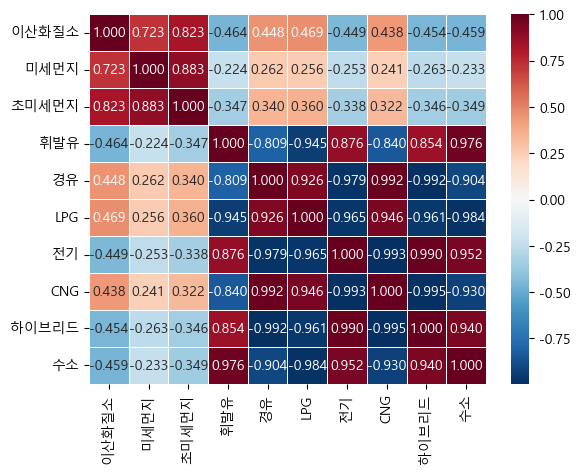

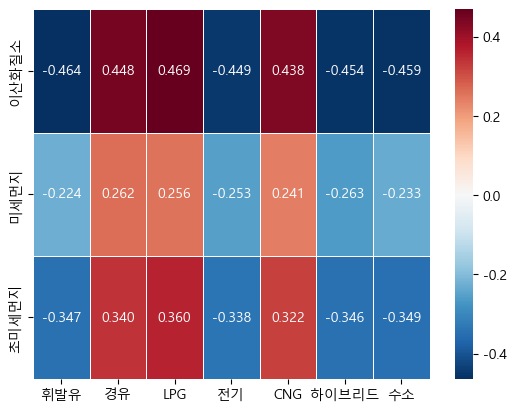

In [6]:
### 상관계수 계산: 자동차 등록 대수 + 대기 오염
# 자동차 등록 대수, 대기오염 정보 각 열의 상관계수 계산
df_con_corr = df_con.corr()
display(df_con_corr)

# 자동차 등록 대수, 대기오염 물질만 계산된 상관계수 슬라이싱
df_con_corr_3x7 = df_con_corr.iloc[:3, 3:]

### 히트맵 생성: 자동차 등록 대수 + 대기 오염
# 전체 상관계수 히트맵 생성
sns.heatmap(df_con_corr,
              annot=True, fmt='.3f',  # 히트맵 내에 상관계수 표시
              cmap='RdBu_r',          # 히트맵 색깔 설정
              linewidth=.5)           # 각 칸 사이 선 굵기 설정
plt.show()

# 슬라이싱 된 상관계수를 히트맵으로 만들기
sns.heatmap(df_con_corr_3x7,
              annot=True, fmt='.3f',
              cmap='RdBu_r',
              linewidth=.5)
plt.show()

,이산화질소,미세먼지,초미세먼지,내연기관,친환경,저공해,자동차 합계,내연기관 비율,친환경 비율,저공해 비율
이산화질소,1.000000,0.723058,0.822926,0.354504,-0.453661,0.469146,-0.436684,0.434031,-0.453540,0.468543
미세먼지,0.723058,1.000000,0.883395,0.237059,-0.259835,0.256215,-0.213366,0.256551,-0.260369,0.253818
초미세먼지,0.822926,0.883395,1.000000,0.271928,-0.344729,0.359770,-0.325279,0.328978,-0.344982,0.358787
내연기관,0.354504,0.237059,0.271928,1.000000,-0.882058,0.747803,-0.558754,0.934187,-0.884215,0.732697
친환경,-0.453661,-0.259835,-0.344729,-0.882058,1.000000,-0.967669,0.880511,-0.990853,0.999979,-0.963449
저공해,0.469146,0.256215,0.359770,0.747803,-0.967669,1.000000,-0.943891,0.925154,-0.967025,0.999576
자동차 합계,-0.436684,-0.213366,-0.325279,-0.558754,0.880511,-0.943891,1.000000,-0.817864,0.877984,-0.952940
내연기관 비율,0.434031,0.256551,0.328978,0.934187,-0.990853,0.925154,-0.817864,1.000000,-0.991274,0.918558
친환경 비율,-0.453540,-0.260369,-0.344982,-0.884215,0.999979,-0.967025,0.877984,-0.991274,1.000000,-0.962648
저공해 비율,0.468543,0.253818,0.358787,0.732697,-0.963449,0.999576,-0.952940,0.918558,-0.962648,1.000000


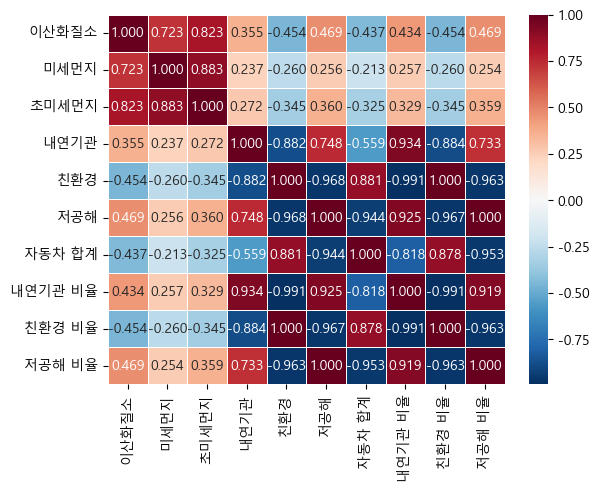

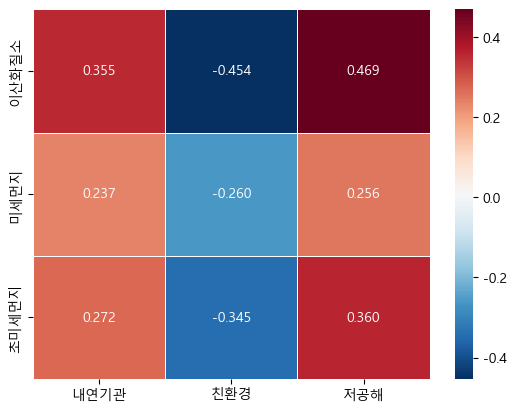

In [7]:
### 상관계수 계산: 자동차 등록 대수 합계 + 대기 오염
# 자동차 연산 데이터와 대기 정보 통합 데이터프레임 생성
df_con_cal_air = air.join(df_con_cal, how='inner')

# 자동차 연산 데이터 각 열의 상관계수 계산
df_con_cal_air_corr = df_con_cal_air.corr()
display(df_con_cal_air_corr)

# 자동차 비율, 대기오염 물질만 계산된 상관계수 슬라이싱
df_con_cal_air_corr_3x3 = df_con_cal_air_corr.iloc[:3, 3:6]

### 히트맵 생성: 연료별 자동차 등록 대수 합계 + 대기 오염
# 전체 상관계수 히트맵 생성
sns.heatmap(df_con_cal_air_corr,
              annot=True, fmt='.3f',
              cmap='RdBu_r',
              linewidth=.5)
plt.show()

# 슬라이싱 된 상관계수를 히트맵으로 만들기
sns.heatmap(df_con_cal_air_corr_3x3,
              annot=True, fmt='.3f',
              cmap='RdBu_r',
              linewidth=.5)
plt.show()

# 6. 시각화

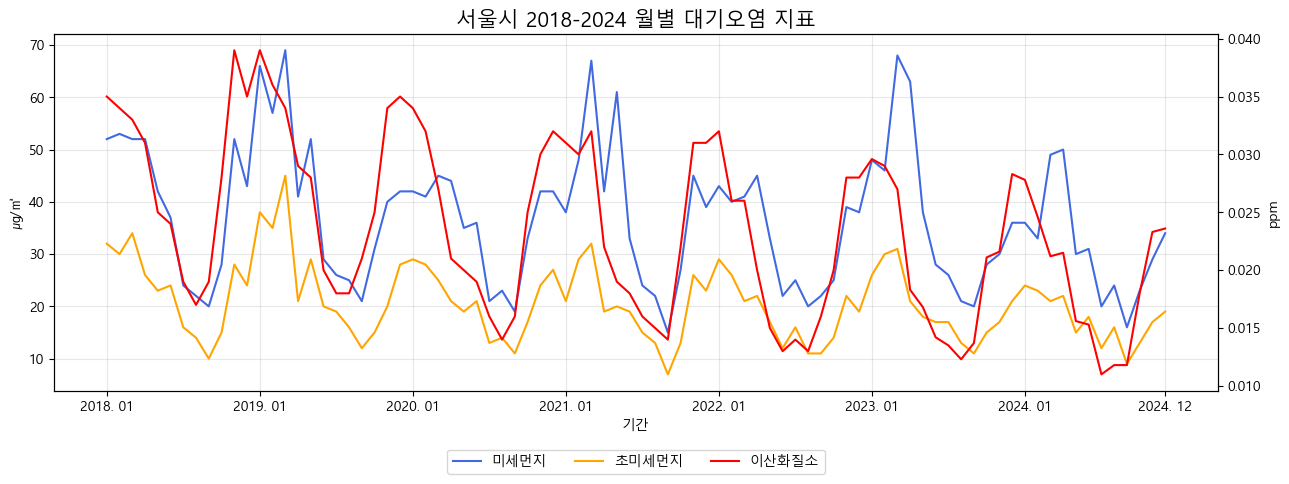

In [8]:
### 1. air 그래프 그리기 (꺾은선 그래프)

# 그래프 사이즈 설정
plt.figure(figsize=(13, 5))

# 그래프 제목 설정
plt.title('서울시 2018-2024 월별 대기오염 지표', fontsize=15)

# 2축 그래프 그리기
ax_PM = plt.gca()   # 현재 활성화된 figure에 axes를 가져옴
air[['미세먼지', '초미세먼지']].plot(ax=ax_PM, color=['royalblue','orange'])  # 미세먼지, 초미세먼지 데이터를 한 축에 표시
ax_NO2 = ax_PM.twinx()  # 두 번째 축 설정
ax_NO2.plot(air.index, air['이산화질소'], color='red', label='이산화질소')  # 두 번째 축에 이산화질소 표시

# 축 이름 설정
ax_PM.set_xlabel('기간')  # x축 레이블 설정
ax_PM.set_ylabel('㎍/㎥') # 첫 번째 y축 레이블 설정
ax_NO2.set_ylabel('ppm')  # 두 번째 y축 레이블 설정

# x축 라벨 간격: 1년 단위로 표시 (air 데이터의 인덱스 사용)
ticks = list(range(0, len(air.index), 12))  # air 인덱스의 길이만큼(step 12) 설정하는 변수 선언
# 마지막 데이터 포인트의 인덱스가 ticks에 포함되지 않으면 추가
if (len(air.index) - 1) not in ticks:
    ticks.append(len(air.index) - 1)
ax_PM.set_xticks(ticks)   # x축에 ticks의 요소를 지정
ax_PM.set_xticklabels([air.index[i] for i in ticks])  # x축에 ticks의 요소가 순차적으로 출력되도록 for문 사용

# 범례 출력
# 범례 합치기
h1, l1 = ax_PM.get_legend_handles_labels()    # h: handle(범례 핸들), l: label(범례 라벨)
h2, l2 = ax_NO2.get_legend_handles_labels()
# 범례를 그래프 바깥에(x축 아래) 가로로 배치
ax_PM.legend(h1 + h2, l1 + l2, loc='center', bbox_to_anchor=(0.5, -0.2), ncol=3)

# 그래프 배경 - 격자 무늬 설정
ax_PM.grid(True, alpha=0.3)

# 그래프 출력
plt.tight_layout()  # 요소들이 서로 겹치지 않도록 레이아웃 조정
plt.show()

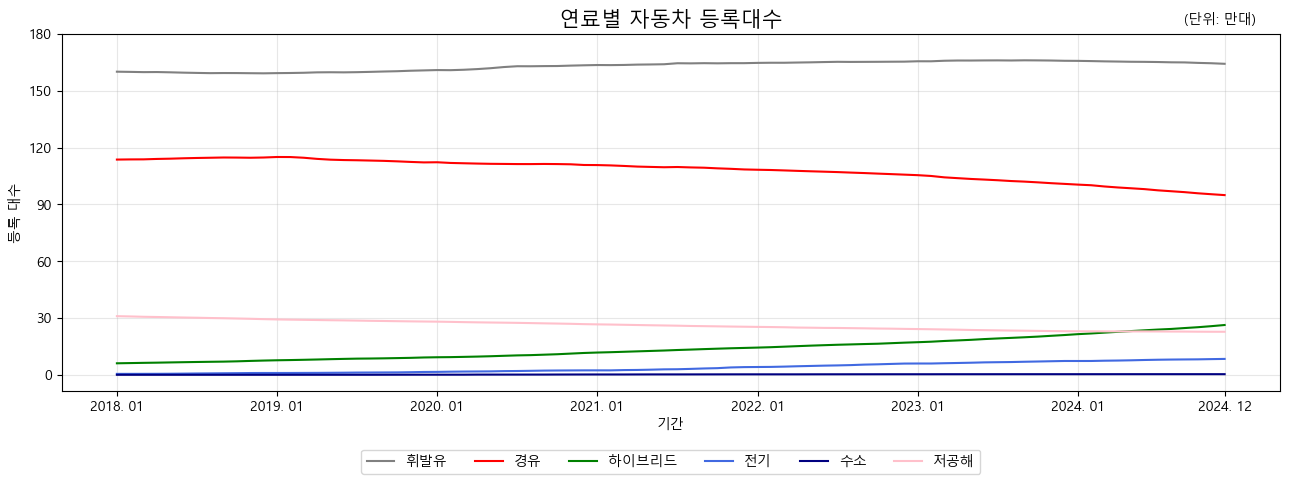

In [9]:
### 2. car 연료별 자동차 등록대수 그래프 그리기 (꺾은선 그래프)

# 그래프 사이즈 설정
plt.figure(figsize=(13, 5))

# 그래프 제목 설정
plt.title('연료별 자동차 등록대수', fontsize=15)

# 그래프 그리기
ax_oil = plt.gca()   # 현재 활성화된 figure에 axes를 가져옴
# 휘발유, 경유, 하이브리드, 전기, 수소 데이터를 한 축에 표시
car[['휘발유', '경유', '하이브리드', '전기', '수소']].plot(ax=ax_oil, color=['gray', 'red', 'green', 'royalblue', 'navy'])
df_con_cal['저공해'].plot(ax=ax_oil, color='pink')      # 저공해 자동차(LPG+CNG) 데이터를 주축에 함께 표시

# 축 이름 설정
ax_oil.set_xlabel('기간')
ax_oil.set_ylabel('등록 대수')

# x축 라벨 간격: 1년 단위로 표시 (car 데이터의 인덱스 사용)
ticks = list(range(0, len(car.index), 12))
if (len(car.index) - 1) not in ticks:
    ticks.append(len(car.index) - 1)
ax_oil.set_xticks(ticks)
ax_oil.set_xticklabels([car.index[i] for i in ticks])

# 첫 번째 y축 눈금 위치와 라벨 설정 (만대 수준)
ax_oil.set_yticks([0, 300000, 600000, 900000, 1200000, 1500000, 1800000])   # 눈금을 표시할 수치
ax_oil.set_yticklabels(['0', '30', '60', '90', '120', '150', '180'])        # 눈금 라벨 설정

# 그래프 상단에 단위 설명 추가
ax_oil.text(0.98, 1.02, '(단위: 만대)', transform=ax_oil.transAxes, va='bottom', ha='right')

# 범례 출력
ax_oil.legend(loc='center', bbox_to_anchor=(0.5, -0.2), ncol=6)

# 그래프 배경 - 격자 무늬 설정
ax_oil.grid(True, alpha=0.3)

# 그래프 출력
plt.tight_layout()
plt.show()

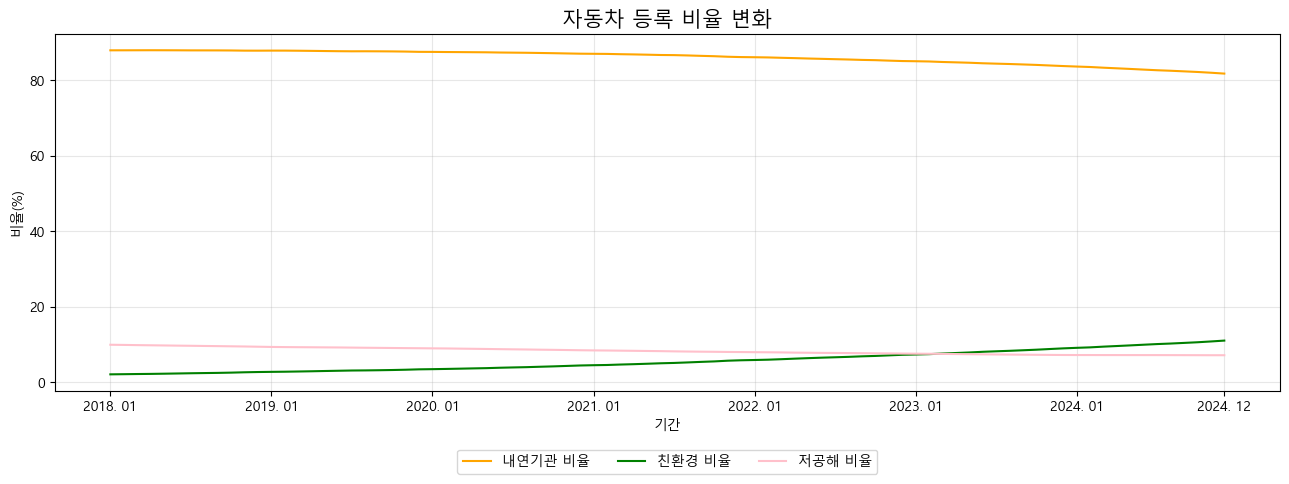

In [10]:
### 3. car 연료별 자동차 비율 그래프 그리기 (꺾은선 그래프)

# 그래프 사이즈 설정
plt.figure(figsize=(13, 5))

# 그래프 제목 설정
plt.title('자동차 등록 비율 변화', fontsize=15)

# 그래프 그리기
ax_ratio = plt.gca()  # 현재 활성화된 figure에 axes를 가져옴
df_con_cal[['내연기관 비율', '친환경 비율', '저공해 비율']].plot(ax=ax_ratio, color=['orange', 'green', 'pink'])

# 축 이름 설정
ax_ratio.set_xlabel('기간')
ax_ratio.set_ylabel('비율(%)')

# x축 라벨 간격: 1년 단위로 표시 (car 데이터의 인덱스 사용)
ticks = list(range(0, len(car.index), 12))
if (len(car.index) - 1) not in ticks:
    ticks.append(len(car.index) - 1)
ax_ratio.set_xticks(ticks)
ax_ratio.set_xticklabels([car.index[i] for i in ticks])

# 범례 출력
ax_ratio.legend(loc='center', bbox_to_anchor=(0.5, -0.2), ncol=3)

# 그래프 배경 - 격자 무늬 설정
ax_ratio.grid(True, alpha=0.3)

# 그래프 출력
plt.tight_layout()
plt.show()

# 7. 결론

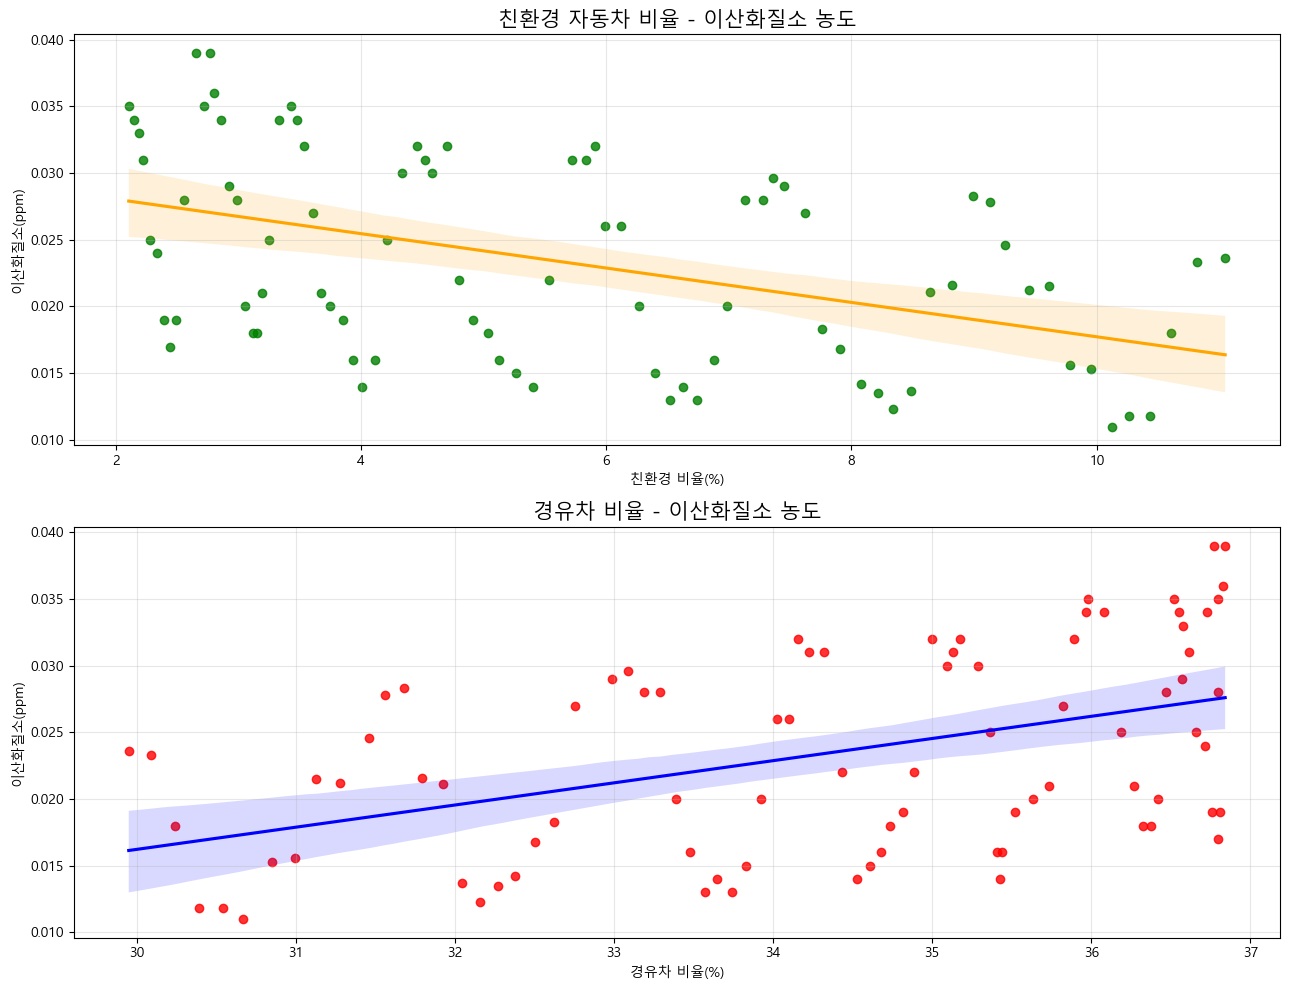

In [11]:
### 결론 그래프 그리기 (친환경 자동차 비율-이산화질소, 경유차 비율-이산화질소) (산점도, 회귀선 표시)

# 그래프를 그릴때 필요한 DataFrame 만들기
eco_conclusion = air[['이산화질소']]    # air DataFrame에 있는 '이산화질소' 칼럼을 가지고 와서 따로 DataFrame으로 만들기
df_conclusion = eco_conclusion.join(df_con_cal['친환경 비율'], how='inner')   # eco_conclusion과 df_con_cal의 '친환경 비율' 칼럼을 조인

NO2_conclusion = air[['이산화질소']]   # air DataFrame에 있는 '이산화질소' 칼럼을 가지고 와서 따로 DataFrame으로 만들기
df_condlusion2 = NO2_conclusion.join(car_diesel_ratio, how='inner')   # NO2_conclusion과 '경유차 비율'을 조인

# 비어 있는 figure 객체 생성(세로로 2개의 그래프 배치)
fig, axs = plt.subplots(2, 1, figsize=(13, 10))

### 위쪽 그래프 그리기 (친환경 자동차 비율-이산화질소)
sns.regplot(x='친환경 비율', y='이산화질소', data=df_conclusion, ax=axs[0],   # x, y축, 사용 데이터 지정, 위쪽 그래프
            scatter_kws={'color': 'green'},    # 산점도 점의 색상을 초록색으로 설정
            line_kws={'color': 'orange'},      # 회귀선의 색상을 오렌지색으로 설정
            fit_reg=True)                      # 회귀선의 신뢰구간을 출력하지 않으려면 ci=None 추가할 것
axs[0].set_title('친환경 자동차 비율 - 이산화질소 농도', fontsize=15) # axs[0] 그래프 제목 설정
axs[0].set_xlabel('친환경 비율(%)')   # x축 제목 설정
axs[0].set_ylabel('이산화질소(ppm)')  # y축 제목 설정
axs[0].grid(True, alpha=0.3)          # 격자 무늬 배경 설정

### 아래쪽 그래프 그리기(경유차 비율-이산화질소)
sns.regplot(x='경유차 비율', y='이산화질소', data=df_condlusion2, ax=axs[1],    # x, y축, 사용 데이터 지정, 아래쪽 그래프
            scatter_kws={'color': 'red'},      # 산점도 점의 색상을 빨간색으로 설정
            line_kws={'color': 'blue'},        # 회귀선의 색상을 파란색으로 설정
            fit_reg=True)
axs[1].set_title('경유차 비율 - 이산화질소 농도', fontsize=15)
axs[1].set_xlabel('경유차 비율(%)')
axs[1].set_ylabel('이산화질소(ppm)')
axs[1].grid(True, alpha=0.3)

# 그래프 출력
plt.tight_layout()
plt.show()